<div style="box-sizing:border-box;max-width:100%;margin:0 0 8px;padding:4px 0;color:inherit;line-height:1.35;"><img src="https://thetahat.ru/images/logo_thetahat.png" alt="ThetaHat" style="display:block!important;width:52px!important;max-width:52px!important;height:auto!important;margin:0 0 9px 0!important;padding:0!important;"><div style="display:flex;align-items:center;justify-content:space-between;flex-wrap:wrap;gap:8px 12px;"><span style="min-width:0;color:inherit;font-size:12px;font-weight:700;letter-spacing:0.055em;text-transform:uppercase;"><a href="https://thetahat.ru/courses/ysda-group" style="color:inherit;text-decoration:none;">Школа анализа данных</a>&nbsp;·&nbsp;Машинное обучение</span></div></div>

<h2><span style="display:block;box-sizing:border-box;max-width:100%;padding:16px 22px 17px;border-radius:14px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 50%,#B316B8 100%);color:#FFFFFF;line-height:1.15;font-weight:500;">Домашнее задание 3. Логистическая регрессия.</span></h2>

<div style="box-sizing:border-box;max-width:100%;margin:18px 0 26px;padding:18px 20px;border:1px solid rgba(127, 127, 127, 0.28);border-left:4px solid #F13A3F;border-radius:12px;background:rgba(127, 127, 127, 0.07);color:inherit;">
  <div style="color:inherit;font-size:12px;font-weight:800;letter-spacing:0.08em;text-transform:uppercase;">Общие правила</div>
  <ul style="margin:10px 0 0;padding-left:22px;line-height:1.55;">
    <li>Выполненную работу <strong>в формате <code>ipynb</code></strong> нужно отправить в кабинете студента <a href="https://thetahat.ru/"><strong>на сайте ThetaHat</strong></a>. Инструкция по регистрации на сайте, записи на курс и сдаче домашек есть на странице курса в ЛМС. <strong>Работы, присланные иным способом, не принимаются.</strong> Дедлайны указаны в личном кабинете, они являются строгими.</li>
    <li>Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><strong>руководство по оформлению ДЗ</strong></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.</li>
    <li>Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><strong>правила использования ИИ-инструментов</strong></a> при решении домашнего задания.</li>
    <li>Выполнять задание необходимо полностью самостоятельно. <strong>При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф согласно правилам на странице курса.</strong></li>
    <li>Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/thetagrader"><img src="https://thetahat.ru/images/ai_eval_small.png" style="display:inline;vertical-align:middle;" alt="ThetaGrader"></a> <a href="https://thetahat.ru/thetagrader"><strong>ThetaGrader</strong></a>. Результаты проверки будут отправлены вам в течение 1-2 суток после дедлайна. После вы можете исправить ошибки или аргументировать свое мнение и отправить на проверку проверяющему. Подробнее на странице курса в ЛМС.</li>
    <li>Никакой код из данного задания при проверке запускаться не будет. <em>Если код не выполнен, недописан и т.д., то он не оценивается.</em></li>
  </ul>
  </br>
    
  <div style="color:inherit;font-size:12px;font-weight:800;letter-spacing:0.08em;text-transform:uppercase;">Правила заполнения ноутбука</div>
  <ul style="margin:8px 0 0;padding-left:22px;line-height:1.55;">
    <li>Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.</li>
    <li>Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены <code>&lt;...&gt;</code>.</li>
    <li>Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках. Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.</li>
    <li>В markdown-ячейках, содержащих описание задачи, находятся специальные отметки, которые <strong style="color:red;">запрещается модифицировать</strong>.</li>
    <li>Решение теоретических задач оформляйте в markdown-ячейках в формате $\LaTeX$. При решении можно использовать ИИ-инструменты для оформления написанного самостоятельно решения, например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.</li>
    <li>При нарушении данных правил работа может получить 0 баллов.</li>
  </ul>
</div>

## 🟢 <font color="green">Часть M</font>

Дедлайн по этой части **во вторник 06.10 в 16:00**. Дедлайн по части L в субботу 10.10 в 23:59. Подробнее в описании курса в ЛМС.


**Баллы эту часть задания:**

* Задача 1 &mdash; 40 баллов;
* Задача 2 &mdash; 20 баллов.

In [68]:
import warnings

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as sps
import seaborn as sns
from sklearn import metrics
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_blobs
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PolynomialFeatures, StandardScaler


from notebook_logreg_tools import (
    measure_time,
    save_model_and_get_size,
    plot_compare_model_performance,
    ModelBenchmark,
    visualize_data,
    plot_logreg_coefficients,
    plot_logit_linearity_check,
    plot_decision_boundary,
)


sns.set(style="whitegrid", palette="Set2")

In [2]:
# Bot check

# HW_ID: ysda_ml1_task_m3
# Система проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так система проверит, что ты ничего не перепутал, и отправляешь финальную версию,
# а не промежуточную. После отправки работы со статусом final до дедлайна все 
# еще можно вносить исправления и отправлять повторно.

# Никакие значения в этой ячейке не влияют на факт сдачи работы.

---

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1, 2**
1. [ссылка](https://p.ip.fi/MVzy)
    - Построение графиков
    - Консультация по pandas
    - Разбор теории


---
### <span style="display:inline-block;padding:6px 13px;border-radius:999px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 55%,#B316B8 100%);color:#FFFFFF;font-size:16px;font-weight:700;line-height:1.2;">Задача 1</span>

*Для начала посмотрим на простых примерах, как работает логистическая регрессия, и поймем некоторые ее важные свойства.*

*Перед выполнением задачи ознакомтесь с ноутбуком по логистической регрессии с занятия.*

> Одно из интересных свойств модели логистической регрессии — *при соблюдении её предположений* она дает возможность получать **несмещенные оценки вероятностей** принадлежности объекта к определенному классу, близкие к идеально скалиброванным. Напомним, модель называется идеально скалиброванной в следующем случае. Рассмотрим объект $x$ и соответствующее предсказание вероятности $\widehat{p}(x)$ для класса 1. Если взять небольшую окрестность объекта $x$, то доля объектов класса 1 в этой окрестности будет приблизительно равна $\widehat{p}(x)$.  

Далее проверим это свойство на конкретных примерах.

С помощью кода ниже сгенерируйте данные, состоящие из одного вещественного признака и бинарного таргета.

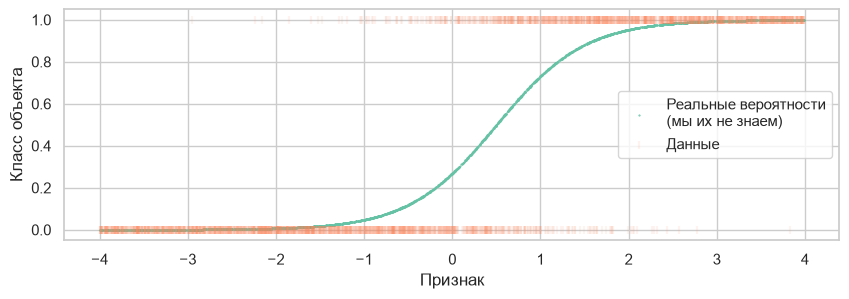

In [3]:
sample_size = 3_000  # Размер выборки

# Признаки
X_train = np.random.uniform(low=-4, high=4, size=(sample_size, 1))

# Таргет
y_mean_true = 1 / (1 + np.exp(1 - 2 * X_train.ravel()))
y_train = np.random.binomial(n=1, p=y_mean_true)

plt.figure(figsize=(10, 3))
plt.scatter(X_train, y_mean_true, marker=".", s=1, label="Реальные вероятности\n(мы их не знаем)")
plt.scatter(X_train, y_train, marker="|", alpha=0.1, label="Данные")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend();

Обучите логистическую регрессию, используя реализацию из `sklearn`, при этом свободный коэффициент должен присутствовать в модели. Укажите также `penalty=None`.

*Делить данные на обучающую и тестовую части в данном случае не нужно, поскольку цель данной задачи &mdash; посмотреть, как модель представляет исходные данные, а не оценить ее качество.*

In [13]:
model = LogisticRegression(C=np.inf)
model.fit(X_train, y_train)

predictions = model.predict(X_train)
probabilities = model.predict_proba(X_train)

Напечатайте оценку коэффициентов из обученной модели

In [10]:
model

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [11]:
print("Intercept:", model.intercept_)
print("W:", model.coef_)

Intercept: [-0.89022721]
W: [[1.94153984]]


Вспомним, обученная модель представляет собой функцию $\widehat{p}: \mathbb{R} \to [0, 1]$, которая для каждого объекта $x \in \mathbb{R}$ возвращает для него оценку вероятности класса 1. Постройте график этой функции.

Ниже объявлена сетка значений  $x \in \mathbb{R}$ для построения графика. На этом же графике:
* постройте предсказания вероятностей класса 1 (бинаризация оценок вероятностей),
* отобразите обучающую выборку.

Похожий график есть в ноутбуке с занятия.

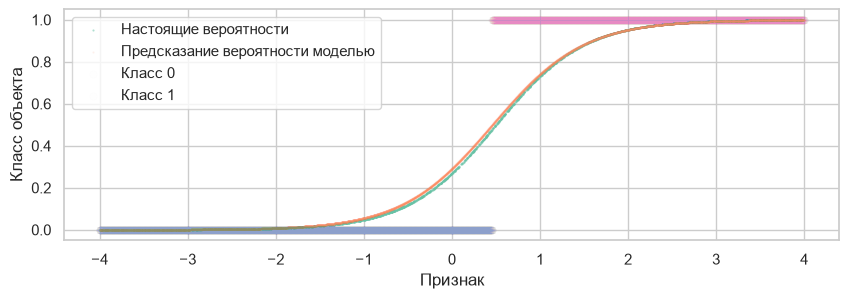

In [50]:
X_grid = np.linspace(-4, 4, 10_000).reshape((-1, 1))
y_predicted_prob = model.predict_proba(X_grid) 
y_predicted = model.predict(X_grid) 

plt.figure(figsize=(10, 3))
plt.scatter(X_train, y_mean_true, alpha=0.5, s=0.3, label="Настоящие вероятности")
plt.scatter(X_grid, y_predicted_prob[:,1], alpha=0.1, s=0.3, label="Предсказание вероятности моделью")
plt.scatter(X_grid[y_predicted == 0], np.zeros_like(X_grid[y_predicted == 0]), s=30, label="Класс 0", alpha=0.002)
plt.scatter(X_grid[y_predicted == 1], np.ones_like(X_grid[y_predicted == 1]), s=30, label="Класс 1", alpha=0.002)

plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend();

Разбейте отрезок $[-4, 4]$ на одинаковые бины длины длины 0.2 и для каждого бина посчитайте долю класса 1 среди объектов обучающей выборки, попавших в данный бин. Полученные значения добавьте на график предсказаний вероятностей и сравните эти графики. Проинтерпретируйте полученные результаты.

<br/>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Кликни для показа подсказки</summary>

Может помочь <code>np.digitize</code> и метод <code>groupby</code> для таблиц <code>pandas</code>. Рекомендуем посмотреть <a href="https://thetahat.ru/courses/python">обучающие ноутбуки</a> по библиотекам.

</details>

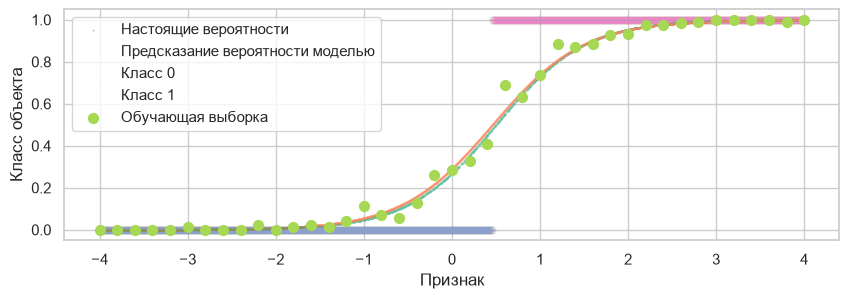

In [58]:
x_binned = np.round(X_train.ravel()  / 0.2) * 0.2
centers, groups = np.unique(x_binned, return_inverse=True)

total = np.bincount(groups)
ones = np.bincount(groups, weights=(y_train.ravel() == 1))
fraction = ones / total

plt.figure(figsize=(10, 3))
plt.scatter(X_train, y_mean_true, alpha=0.5, s=0.3, label="Настоящие вероятности")
plt.scatter(X_grid, y_predicted_prob[:,1], alpha=0.1, s=0.3, label="Предсказание вероятности моделью")
plt.scatter(X_grid[y_predicted == 0], np.zeros_like(X_grid[y_predicted == 0]), s=30, label="Класс 0", alpha=0.002)
plt.scatter(X_grid[y_predicted == 1], np.ones_like(X_grid[y_predicted == 1]), s=30, label="Класс 1", alpha=0.002)
plt.scatter(centers, fraction, s=50, label="Обучающая выборка")

plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend();

Позволяют ли посчитанные выше значения построить калибровочную кривую? Если да, поясните и постройте ее график. Если нет, поясните разницу, реализуйте самостоятельно калибровочную кривую и постройте ее график.

<br/>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Кликни для показа подсказки</summary>

Посмотри на определение калибровочной кривой и на бины.

</details>

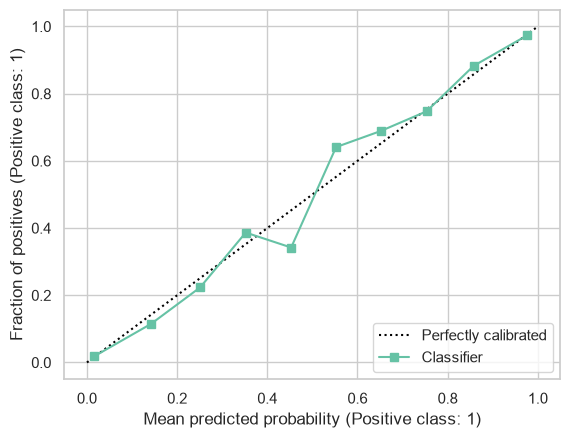

In [87]:
CalibrationDisplay.from_predictions(
    y_train,
    model.predict_proba(X_train)[:, 1],
    n_bins=10,
    strategy="uniform",
)
plt.show()

In [83]:
calibrated = CalibratedClassifierCV(
    LogisticRegression(C=float("inf")),
    method="sigmoid",
    cv=5,
)
calibrated.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LogisticRegression(C=inf)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...x73d39dd44d70>, <sklearn

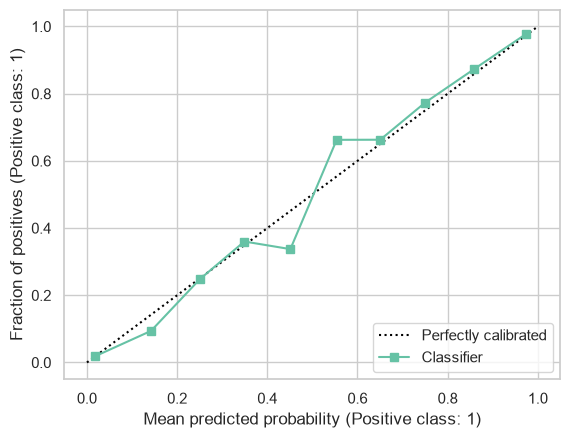

In [86]:
CalibrationDisplay.from_predictions(
    y_train,
    calibrated.predict_proba(X_train)[:, 1],
    n_bins=10,
    strategy="uniform",
)
plt.show()

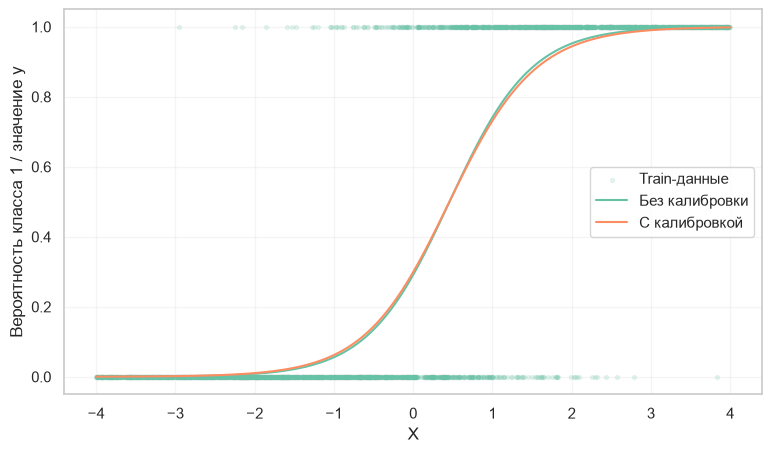

In [84]:
x = X_train.ravel()

p_original = model.predict_proba(X_grid)[:, 1]
p_calibrated = calibrated.predict_proba(X_grid)[:, 1]

plt.figure(figsize=(9, 5))

plt.scatter(x, y_train, s=8, alpha=0.15, label="Train-данные")
plt.plot(X_grid.ravel(), p_original, label="Без калибровки")
plt.plot(X_grid.ravel(), p_calibrated, label="С калибровкой")

plt.xlabel("X")
plt.ylabel("Вероятность класса 1 / значение y")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Повторите проведенное исследование для следующих данных и сравните результаты.

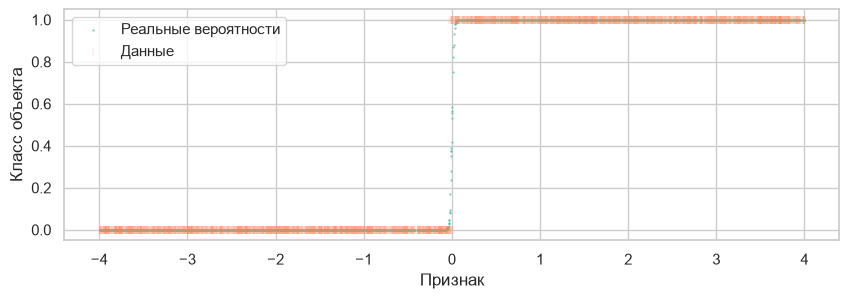

In [88]:
# Признаки
X_train = np.random.uniform(low=-4, high=4, size=(sample_size, 1))

# Таргет
y_mean_true = 1 / (1 + np.exp(-100 * X_train.ravel()))
y_train = np.random.binomial(n=1, p=y_mean_true)

plt.figure(figsize=(10, 3))
plt.scatter(X_train, y_mean_true, marker=".", s=1, label="Реальные вероятности")
plt.scatter(X_train, y_train, marker="|", alpha=0.1, label="Данные")
plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend();

In [89]:
model = LogisticRegression(C=np.inf)
model.fit(X_train, y_train)

predictions = model.predict(X_train)
probabilities = model.predict_proba(X_train)

In [90]:
model

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [91]:
print("Intercept:", model.intercept_)
print("W:", model.coef_)

Intercept: [0.52417473]
W: [[87.16551701]]


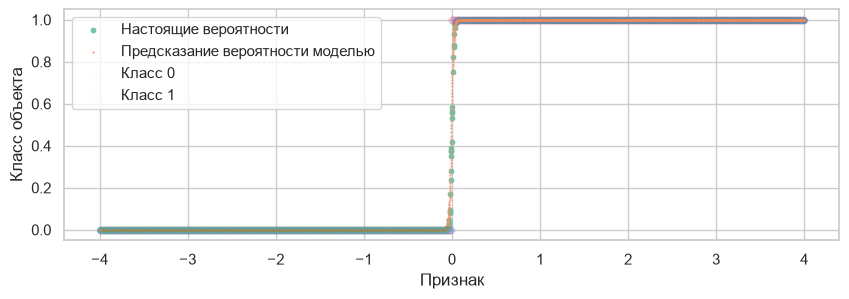

In [97]:
X_grid = np.linspace(-4, 4, 10_000).reshape((-1, 1))
y_predicted_prob = model.predict_proba(X_grid) 
y_predicted = model.predict(X_grid) 

plt.figure(figsize=(10, 3))
plt.scatter(X_train, y_mean_true, alpha=0.9, s=10, label="Настоящие вероятности")
plt.scatter(X_grid, y_predicted_prob[:,1], alpha=0.9, s=0.3, label="Предсказание вероятности моделью")
plt.scatter(X_grid[y_predicted == 0], np.zeros_like(X_grid[y_predicted == 0]), s=30, label="Класс 0", alpha=0.002)
plt.scatter(X_grid[y_predicted == 1], np.ones_like(X_grid[y_predicted == 1]), s=30, label="Класс 1", alpha=0.002)

plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend();

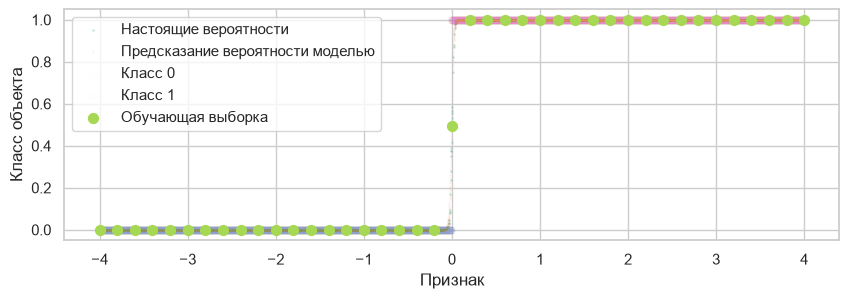

In [98]:
x_binned = np.round(X_train.ravel()  / 0.2) * 0.2
centers, groups = np.unique(x_binned, return_inverse=True)

total = np.bincount(groups)
ones = np.bincount(groups, weights=(y_train.ravel() == 1))
fraction = ones / total

plt.figure(figsize=(10, 3))
plt.scatter(X_train, y_mean_true, alpha=0.5, s=0.3, label="Настоящие вероятности")
plt.scatter(X_grid, y_predicted_prob[:,1], alpha=0.1, s=0.3, label="Предсказание вероятности моделью")
plt.scatter(X_grid[y_predicted == 0], np.zeros_like(X_grid[y_predicted == 0]), s=30, label="Класс 0", alpha=0.002)
plt.scatter(X_grid[y_predicted == 1], np.ones_like(X_grid[y_predicted == 1]), s=30, label="Класс 1", alpha=0.002)
plt.scatter(centers, fraction, s=50, label="Обучающая выборка")

plt.xlabel("Признак")
plt.ylabel("Класс объекта")
plt.legend();

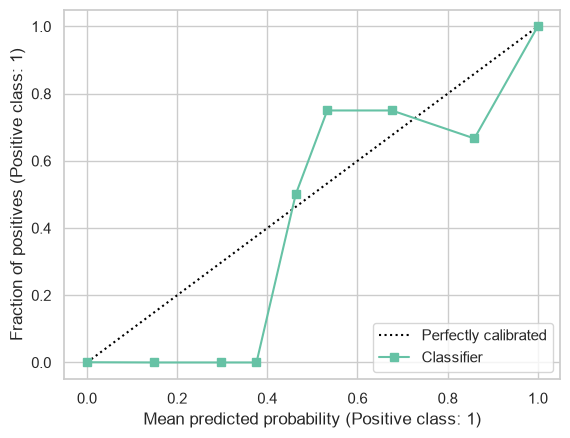

In [99]:
CalibrationDisplay.from_predictions(
    y_train,
    model.predict_proba(X_train)[:, 1],
    n_bins=10,
    strategy="uniform",
)
plt.show()

In [100]:
calibrated = CalibratedClassifierCV(
    LogisticRegression(C=float("inf")),
    method="sigmoid",
    cv=5,
)
calibrated.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LogisticRegression(C=inf)
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...x73d39d7e4410>, <sklearn

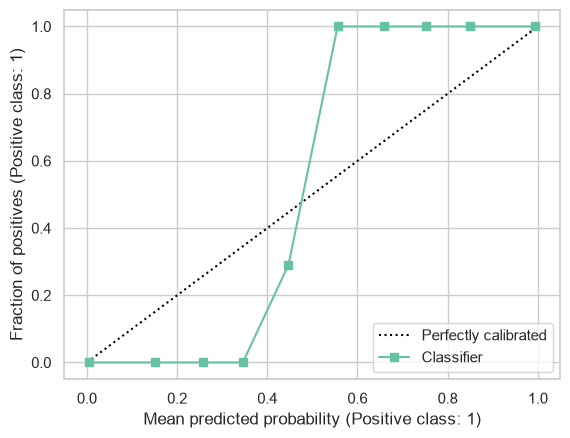

In [101]:
CalibrationDisplay.from_predictions(
    y_train,
    calibrated.predict_proba(X_train)[:, 1],
    n_bins=10,
    strategy="uniform",
)
plt.show()

**Выводы:**

На данных, которые изначально хорошо описываются сигмоидой, logreg работает очень хорошо.
Калибровка при этом становится достаточно бессмысленной, обученная модель уже относительно неплохо откалибрована.

В предельном случае, когда сигмоида приближена к sgn(x), модель также хорошо делает предсказания.
Однако из-за крайне узкого коридора, где вообще есть неопределенности, вероятности в этом коридоре перестают иметь надежный смысл.

---
### <span style="display:inline-block;padding:6px 13px;border-radius:999px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 55%,#B316B8 100%);color:#FFFFFF;font-size:16px;font-weight:700;line-height:1.2;">Задача 2</span>

Продолжим исследовать модель логистической регрессии. Сгенерируем данные, состоящие из двух бинарных признаков и бинарного таргета

In [102]:
probs = np.random.uniform(size=8)
probs /= probs.sum()
probs

x = np.random.choice(np.arange(8), p=probs, size=10_000)
data = pd.DataFrame(
    np.unpackbits(np.array(x.reshape(-1, 1), dtype=">i8").view(np.uint8), axis=1)[:, -3:],
    columns=["feature_1", "feature_2", "target"],
)
data.head()

,feature_1,feature_2,target
0,1,0,0
1,0,1,1
2,0,1,1
3,0,0,1
4,1,1,0


Особенность таких данных &mdash; конечное число *возможных различных* объектов. В данном случае их всего 4, по количеству всех возможных комбинаций значений признака. Соответственно, любой моделью мы можем сделать только 4 *различных* предсказания вероятности класса 1. Исследуем, как с этим справляется логистическая регрессия.

Сначала для сравнения посчитайте долю класса 1 для каждой категории объектов.


<br/>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Кликни для показа подсказки</summary>

    Используйте <code>pd.pivot_table</code>. Рекомендуем посмотреть <a href="https://thetahat.ru/courses/python">обучающие ноутбуки</a> по библиотекам.

</details>

In [111]:
table = data.pivot_table(index="feature_1", columns="feature_2", values="target", aggfunc="mean")
table

feature_2,0,1
feature_1,,
0,0.829735,0.399084
1,0.467003,0.313102


In [117]:
data.iloc[:, -1]

0       0
1       1
2       1
3       1
4       0
       ..
9995    0
9996    1
9997    0
9998    0
9999    0
Name: target, Length: 10000, dtype: uint8

Обучите логистическую регрессию с `penalty='none'` и получите предсказания вероятностей для этих четырех типов объектов. Представьте результаты в таком виде, чтобы их удобно было сравнивать с частотами, посчитанными ранее.

In [120]:
model = LogisticRegression(C=np.inf)
model.fit(data.iloc[:, :-1], data.iloc[:, -1])

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [124]:
from itertools import product

test = pd.DataFrame(
    product([0, 1], repeat=2),
    columns=["feature_1", "feature_2"],
)
test["target"] = model.predict_proba(test.iloc[:, 0:2])[:, 1]

In [125]:
test_table = test.pivot_table(index="feature_1", columns="feature_2", values="target", aggfunc="mean")
test_table

feature_2,0,1
feature_1,,
0,0.784213,0.434155
1,0.521974,0.187345


Почему результаты существенно отличаются?

Для ответа на этот вопрос распишите формулу, которая задает модель логистической регрессии, указав все параметры. Какое предположение о данных при этом делает логистическая регрессия?

$$
p(\mathbf{x}) =
\frac{1}{
    1 + \exp\!\left[-\left(b + \alpha_1 x_1 + \alpha_2 x_2\right)\right]
}
$$

Для логистической регрессии требуется чтобы данные были линейно разделимы, линейно независимы, получены в результате независимых измерений, а также
чтобы выполнялось условие log-odds.
$$
\log\!\left(\frac{p(\mathbf{x})}{1 - p(\mathbf{x})}\right)
= b + \alpha_1 x_1 + \alpha_2 x_2
$$


То есть величина $\ell_x=\log\!\left(\frac{p(\mathbf{x})}{1 - p(\mathbf{x})}\right)$ должна вести себя линейно по каждому признаку.
Для бинарных $x_1, x_2$, выходит, что эта величина равна:
$$
\begin{aligned}
\ell_{00} &= b, \\
\ell_{01} &= b + \alpha_2, \\
\ell_{10} &= b + \alpha_1, \\
\ell_{11} &= b + \alpha_1 + \alpha_2.
\end{aligned}
$$

Ну, например, $\ell_{11} - \ell_{01} = \ell_{10} - \ell_{00}$  
А изначальные вероятности этому не соответствуют

In [127]:
log_odds = np.log(table / (1 - table))
log_odds

feature_2,0,1
feature_1,,
0,1.583753,-0.409284
1,-0.132180,-0.785656


In [128]:
print(-0.785656 - (-0.132180))
print(-0.409284 - 1.583753)

-0.6534760000000001
-1.993037


Предложите и реализуйте способ модификации данных так, чтобы логистическая регрессия точнее предсказывала частоты, посчитанные ранее.

<br/>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Кликни для показа подсказки</summary>

Подумайте, какое преобразование признаков можно было бы сделать.

</details>

Опишите ваше предложение:

Добавим признак $x_1 x_2$. Тогда логит вероятностей станет
$$
\begin{aligned}
\ell_{00} &= b, \\
\ell_{01} &= b + \alpha_2, \\
\ell_{10} &= b + \alpha_1, \\
\ell_{11} &= b + \alpha_1 + \alpha_2 + \alpha_{12}.
\end{aligned}
$$

И жесткая изначальная связь между бинарными признаками должна разбиться.  

Реализация:

In [137]:
amended_data = data.copy()
amended_data["cross"] = data["feature_1"] * data["feature_2"]
amended_data = amended_data.drop(columns="target")

model = LogisticRegression(C=np.inf)
model.fit(amended_data, data["target"])

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [138]:
from itertools import product

test = pd.DataFrame(
    product([0, 1], repeat=2),
    columns=["feature_1", "feature_2"],
)
test["cross"] = test["feature_1"] * test["feature_2"]
test["target"] = model.predict_proba(test.iloc[:, 0:3])[:, 1]
test.pivot_table(
    index="feature_1",
    columns="feature_2",
    values="target",
)

feature_2,0,1
feature_1,,
0,0.829861,0.399056
1,0.466978,0.313079


**Выводы:**

Для лог регрессии важно соблюдать требования к данным: линейная разделимость, линейная независимость, независимость сэмплов и условие log-odds.
Последнее можно поправить после сбора данных добавлением степеней свободы. В данном случае это существенно улучшило модель.

<div style="box-sizing:border-box;max-width:100%;margin-top:42px;padding:18px 0 4px;border-top:1px solid rgba(127, 127, 127, 0.28);color:inherit;font-size:0.9em;line-height:1.5;"><img src="https://thetahat.ru/images/logo_thetahat.png" alt="ThetaHat" style="display:block!important;width:34px!important;max-width:34px!important;height:auto!important;margin:0 0 9px 0!important;padding:0!important;">© 2026 команда <a href="https://thetahat.ru/" style="color:inherit;font-weight:750;text-decoration:underline;text-decoration-color:#F13A3F;text-underline-offset:3px;">ThetaHat</a> для курса ML-1 ШАД</div>